In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
# step-0: spread out some points at random
num_points = 50
R = 100
step_size = 0.01  # how much they move in each time step
N_dim = 1  # in how many dims are we working?
N_steps = 1000

np.random.seed(2)
pos = np.sort(R*np.random.random(num_points))
y = np.zeros_like(pos)



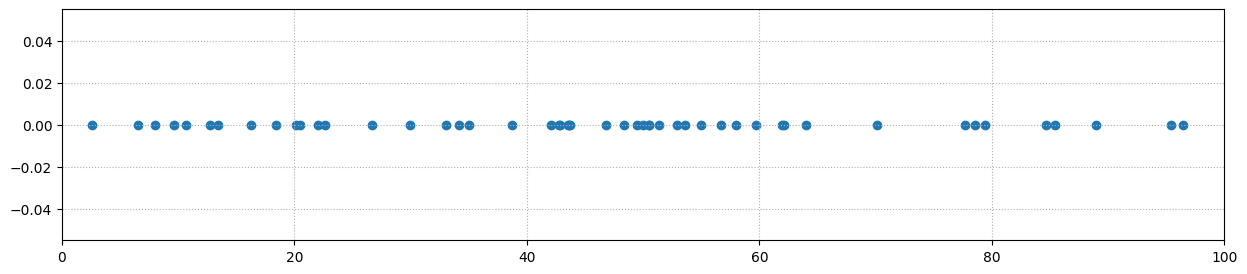

In [3]:
def plot_positions(pos):
    fig, ax = plt.subplots(figsize=(15,3))
    ax.scatter(pos, y)
    ax.grid(ls=":")
    ax.set_xlim(0, R)

plot_positions(pos)



In [4]:
def compute_net_force(pos):
    F_net = np.zeros_like(pos)
    for i, posN in enumerate(pos):
        dist = pos - posN
        
        dist_left = dist[dist < 0]
        dist_right = dist[dist > 0]
        
        F_net[i] = np.sum(np.abs(1 / dist_left**N_dim)) - np.sum(np.abs(1 / dist_right**N_dim))
        
    return F_net

In [ ]:
for step in tqdm(range(N_steps)):
    effective_step_size = step_size * (1 - step / (N_steps*50))
    
    new_pos = pos + effective_step_size * compute_net_force(pos)
    new_pos = np.clip(new_pos, a_min=0, a_max=R)  # respect the boundaries

100%|██████████| 1000/1000 [00:00<00:00, 1663.10it/s]


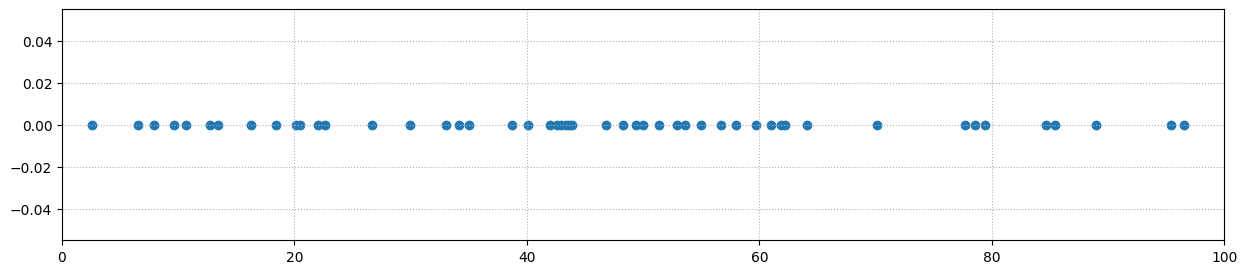

In [6]:
plot_positions(new_pos)



In [120]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# LEO parameters
num_points = 50
R_earth = 6371      
altitude = 550       
R = R_earth + altitude # orbital radius = Earth radius + altitude

step_size = 0.01
N_dim = 2
N_steps = 1000

np.random.seed(2)

# evenly spaced angles around the circle
angles = np.linspace(0, 2*np.pi, num_points, endpoint=False)

pos = np.vstack([R*np.cos(angles), R*np.sin(angles)]).T



In [123]:
def plot_positions(pos):
    fig, ax = plt.subplots(figsize=(7,7))

    # Earth
    earth = plt.Circle((0,0), R_earth, color='blue', alpha=0.3)
    ax.add_patch(earth)

    # Orbit circle
    orbit = plt.Circle((0,0), R, fill=False, ls="--")
    ax.add_patch(orbit)

    # Satellites
    ax.scatter(pos[:,0], pos[:,1], color='red')

    ax.set_aspect("equal")
    ax.grid(ls=":")
    ax.set_xlim(-R-500, R+500)
    ax.set_ylim(-R-500, R+500)




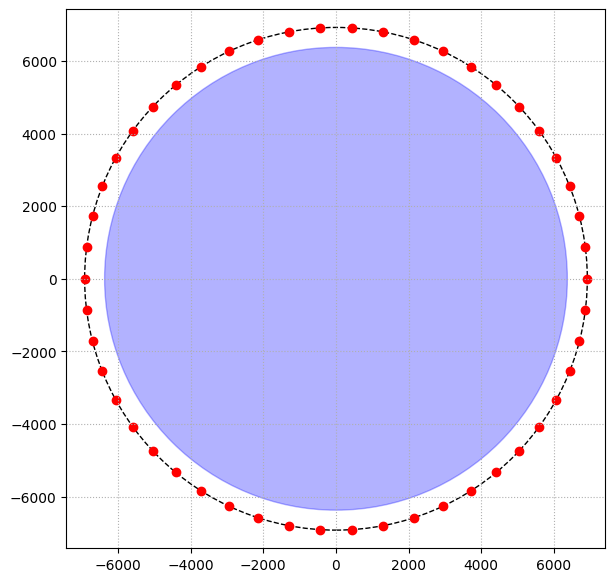

In [124]:
plot_positions(pos)


In [125]:
def compute_net_force(pos):
    F_net = np.zeros_like(pos)

    for i, p in enumerate(pos):
        dist_vec = pos - p

        mask = np.any(dist_vec != 0, axis=1)
        dist_vec = dist_vec[mask]

        dist = np.linalg.norm(dist_vec, axis=1)

        magnitudes = 1 / (dist**N_dim)


        directions = dist_vec / dist[:, None]


        F_net[i] = np.sum(magnitudes[:, None] * directions, axis=0)

    return F_net


In [126]:
pos_current = pos.copy()

for step in tqdm(range(N_steps)):
    effective_step_size = step_size * (1 - step / (N_steps*50))

    forces = compute_net_force(pos_current)
    new_pos = pos_current + effective_step_size * forces

    radii = np.linalg.norm(new_pos, axis=1)
    new_pos = (new_pos.T * (R / radii)).T

    pos_current = new_pos


100%|██████████| 1000/1000 [00:00<00:00, 1127.60it/s]


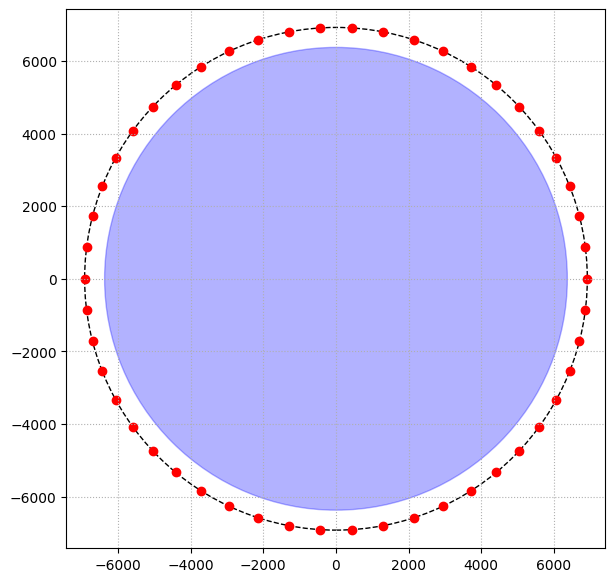

In [127]:
plot_positions(pos_current)

In [128]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D

# LEO parameters
num_points = 50
R_earth = 6371
altitude = 550
R = R_earth + altitude

step_size = 0.01
N_dim = 2
N_steps = 1000

np.random.seed(2)

# evenly spaced points using Fibonacci sphere
indices = np.arange(0, num_points, dtype=float) + 0.5
phi = np.arccos(1 - 2*indices/num_points)
theta = np.pi * (1 + 5**0.5) * indices

x = R * np.sin(phi) * np.cos(theta)
y = R * np.sin(phi) * np.sin(theta)
z = R * np.cos(phi)

pos = np.vstack([x, y, z]).T


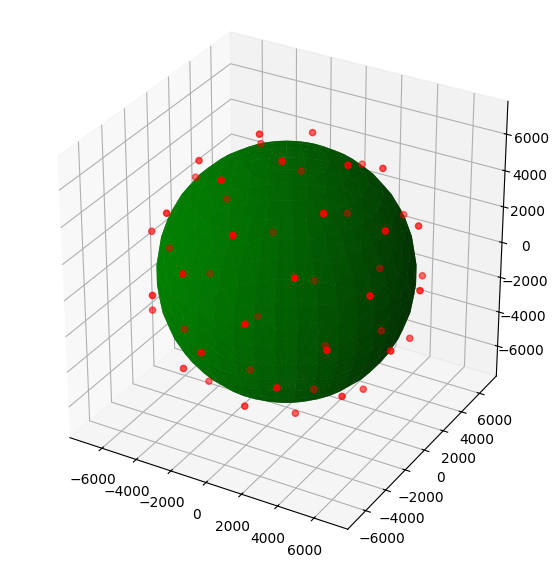

In [129]:
def plot_positions_3d(pos):
    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot(111, projection='3d')

    # Satellites
    ax.scatter(pos[:,0], pos[:,1], pos[:,2], color='red')

    # Earth sphere
    u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
    xe = R_earth * np.cos(u) * np.sin(v)
    ye = R_earth * np.sin(u) * np.sin(v)
    ze = R_earth * np.cos(v)
    ax.plot_surface(xe, ye, ze, color='green', alpha=0.9)

    ax.set_box_aspect([1,1,1])
    plt.show()

plot_positions_3d(pos)


In [130]:
def compute_net_force(pos):
    F_net = np.zeros_like(pos)

    for i, p in enumerate(pos):

        dist_vec = pos - p

        mask = np.any(dist_vec != 0, axis=1)

        dist_vec = dist_vec[mask]

        dist = np.linalg.norm(dist_vec, axis=1)

        magnitudes = 1 / (dist**N_dim)

        directions = dist_vec / dist[:, None]

        F_net[i] = np.sum(magnitudes[:, None] * directions, axis=0)

    return F_net


100%|██████████| 1000/1000 [00:00<00:00, 1150.59it/s]


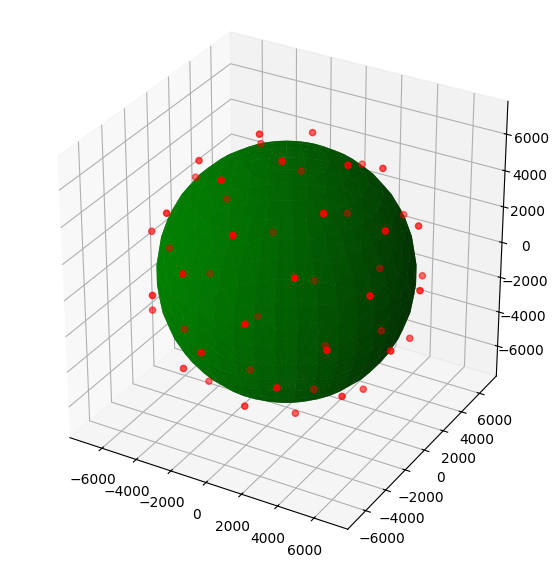

In [ ]:
pos_current = pos.copy()

for step in tqdm(range(N_steps)):
    effective_step_size = step_size * (1 - step / (N_steps*50))

    forces = compute_net_force(pos_current)
    new_pos = pos_current + effective_step_size * forces

    radii = np.linalg.norm(new_pos, axis=1)
    new_pos = (new_pos.T * (R / radii)).T

    pos_current = new_pos


plot_positions_3d(pos_current)
